### Name: Shiva

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [3]:
import os

# List the contents of the downloaded directory to find the CSV file
print(os.listdir(path))

# Correcting the filename to 'IMDB Dataset.csv'
df = pd.read_csv(os.path.join(path, 'IMDB Dataset.csv'))

['IMDB Dataset.csv']


In [4]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Steps:
- tokenize the text
- remove stop words
- lemitise token now

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token.isalpha()]
    tokens = [token for token in tokens if token not in stop_words]
    return " ".join(tokens)

df['clean_review'] = df['review'].apply(preprocess_text)
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer ha mentioned watching oz episode ...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wa wonderful way spend time hot summer...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [19]:
df.to_csv('clean_data.csv')

In [7]:
# we get clean dataset but model train on numerical value
# so apply tfidf
vectorizer= TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

In [24]:
import pickle

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [8]:
x_train, x_test, y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
model= MultinomialNB()
model.fit(x_train,y_train)

MultinomialNB()

In [10]:
prediction=model.predict(x_test)
print(y_test)
print()
print(prediction)

33553    positive
9427     positive
199      negative
12447    positive
39489    negative
           ...   
28567    negative
25079    positive
18707    positive
15200    negative
5857     positive
Name: sentiment, Length: 10000, dtype: object

['negative' 'positive' 'negative' ... 'positive' 'negative' 'positive']


In [11]:
print('classification matrix: \n')
print(classification_report(y_test,prediction))

classification matrix: 

              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      4961
    positive       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [12]:
## confusion matrix
prediction = model.predict(x_test) # Re-calculate prediction for the test set
print('confusion matrix: \n')
print(confusion_matrix(y_test,prediction))

confusion matrix: 

[[4190  771]
 [ 716 4323]]


- test on randon /real time data

In [13]:
text=['This movie was fantastic and inspiring.I am joking!!! actually its very bad']
clean=preprocess_text(text[0])
vector= vectorizer.transform([clean])
prediction=model.predict(vector)
print('Predicted Sentiment: ', prediction[0])

Predicted Sentiment:  positive


## finding best model

In [14]:
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,VotingClassifier,StackingClassifier
from sklearn.svm import SVC
# from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
# from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Define a couple of simple estimators to use as placeholders for ensemble methods
# You can replace these with more appropriate base models as needed.
# bc = BaggingClassifier(random_state=42)
lr = LogisticRegression(random_state=42, solver='liblinear')

models={
    'naive_bayes': MultinomialNB(),
    'logistic_regression': LogisticRegression(random_state=42, solver='liblinear'),
    'random_forest': RandomForestClassifier(random_state=42),
    'svm': SVC(random_state=42),
    # 'xgboost': XGBClassifier(random_state=42),
    # 'catboost': CatBoostClassifier(random_state=42, verbose=False),
    # 'lightgbm': LGBMClassifier(random_state=42, verbose=-1),
    'knn': KNeighborsClassifier(),
    'decision_tree': DecisionTreeClassifier(random_state=42),
    # 'gradient_boosting': GradientBoostingClassifier(random_state=42),
    # 'adaboost': AdaBoostClassifier(random_state=42),
    # 'bagging': BaggingClassifier(random_state=42),
    # 'extra_trees': ExtraTreesClassifier(random_state=42),
    # 'voting': VotingClassifier(estimators=[('bc', bc), ('lr', lr)], voting='hard'),
    # 'stacking': StackingClassifier(estimators=[('bc', bc), ('lr', lr)], final_estimator=LogisticRegression(random_state=42, solver='liblinear')),
    'neural_network': MLPClassifier(random_state=42, max_iter=1000)
}

In [15]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


result1=[]
for name,model in models.items():
  model.fit(x_train,y_train)
  prediction=model.predict(x_test)
  accuracy = accuracy_score(y_test, prediction)
  # Specify pos_label for binary classification with string labels
  precision = precision_score(y_test, prediction, pos_label='positive')
  recall = recall_score(y_test, prediction, pos_label='positive')
  f1 = f1_score(y_test, prediction, pos_label='positive')
  result1.append((name,accuracy,precision,recall,f1))

In [17]:
result_df1=pd.DataFrame(result1,columns=['model','accuracy','precision','recall','f1_score'])
result_df1

,model,accuracy,precision,recall,f1_score
0,naive_bayes,0.8513,0.848645,0.857908,0.853252
1,logistic_regression,0.8865,0.877709,0.900179,0.888802
2,random_forest,0.8490,0.856681,0.841040,0.848788
3,svm,0.8916,0.881978,0.906132,0.893892
4,knn,0.7390,0.724866,0.776940,0.750000
5,decision_tree,0.7139,0.717279,0.713435,0.715352
6,neural_network,0.8706,0.865937,0.879341,0.872588


In [18]:
result_df1.to_csv('comparison_model.csv')

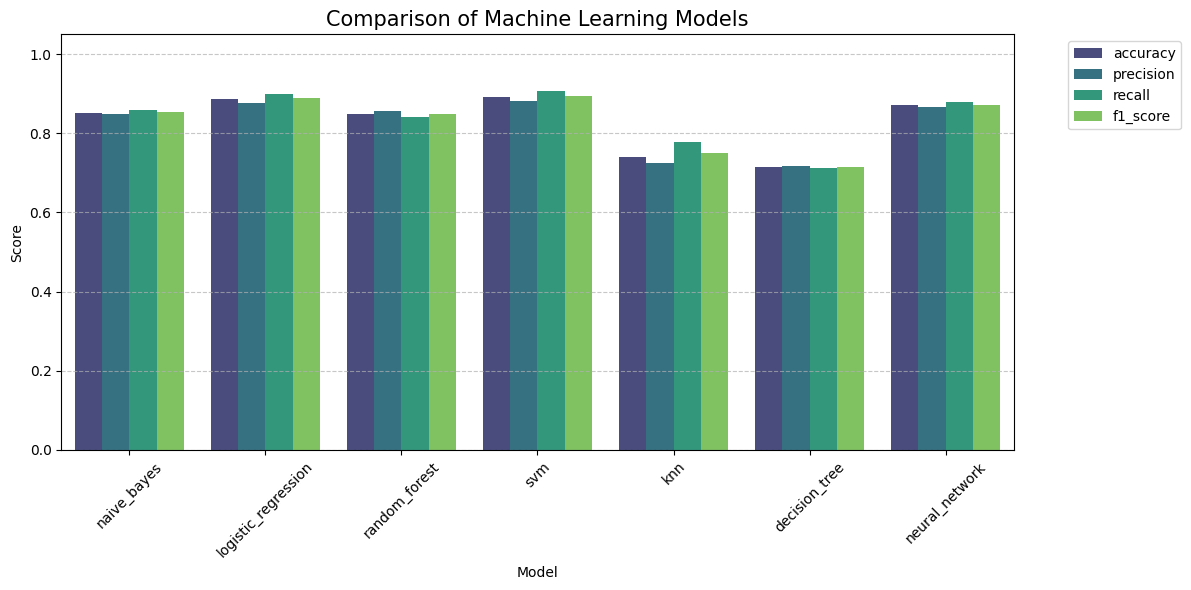

In [20]:
# visualize best model
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reshape the dataframe for easier plotting
df_melted = result_df1.melt(id_vars='model', var_name='Metric', value_name='Score')

# 2. Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='model', y='Score', hue='Metric', palette='viridis')

# 3. Add styling
plt.title('Comparison of Machine Learning Models', fontsize=15)
plt.ylim(0, 1.05) # Metrics are between 0 and 1
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


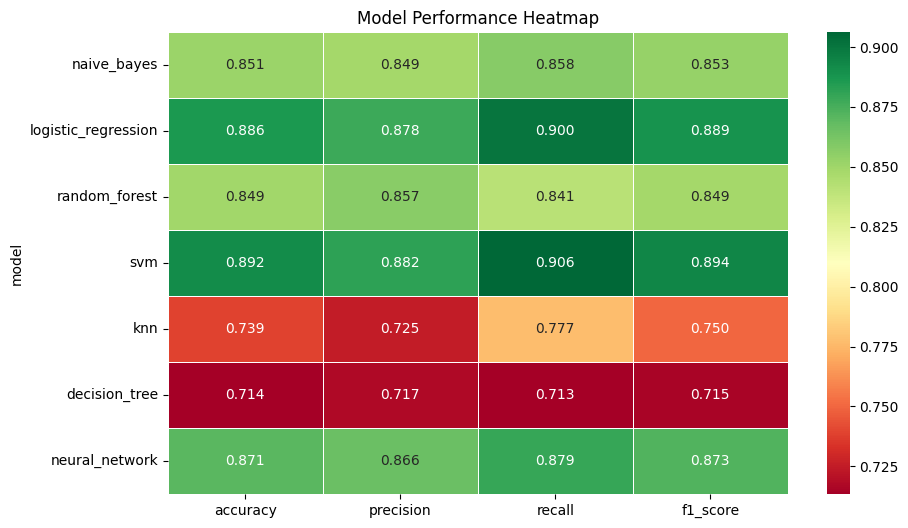

In [21]:
heatmap_data = result_df1.set_index('model')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', fmt='.3f', linewidths=0.5)
plt.title('Model Performance Heatmap')
plt.show()

- from above comparison best model is SVM

In [22]:
model=SVC(random_state=42)
model.fit(x_train,y_train)


SVC(random_state=42)

In [26]:
print(confusion_matrix(y_test,model.predict(x_test)))

[[4350  611]
 [ 473 4566]]


In [23]:
# downloading pickel model
import pickle
with open('svm_model.pkl','wb') as file:
  pickle.dump(model,file)